# Eval Plots — PlanningOrchestrator Benchmark
Laadt MLflow child-runs, groepeert per **agent group** (graph / salesforce / smartsales / orchestrator)
en toont scores, latency, tokens en rationale — vergelijkbaar met de Excel benchmark.

In [107]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('imports ok')
VERSION = "v4-graph-rag-done" 

imports ok


In [108]:
# ── Config ────────────────────────────────────────────────────────────────────
TRACKING_URI = 'sqlite:///C:/Users/AALB/Desktop/mp/graph/graphxmaf/mlflow.db'
EXPERIMENT   = 'graphxmaf-eval'

# Category → agent group (zelfde indeling als Excel)
AGENT_GROUPS = {
    'graph':        ['email', 'calendar', 'files', 'people', 'identity'],
    'salesforce':   ['accounts', 'contacts', 'leads', 'opportunities', 'cases'],
    'smartsales':   ['locations', 'catalog', 'orders'],
    'orchestrator': ['cross-system'],
}

GROUP_ORDER  = ['graph', 'salesforce', 'smartsales', 'orchestrator']
GROUP_COLORS = {
    'graph':        '#3b82f6',
    'salesforce':   '#10b981',
    'smartsales':   '#f59e0b',
    'orchestrator': '#8b5cf6',
}

DIFFICULTY_ORDER = ['simple', 'medium', 'hard']
DIFF_COLORS      = {'simple': '#93c5fd', 'medium': '#3b82f6', 'hard': '#1e3a8a'}

# Geschatte GPT-4o prijs (USD per 1 000 tokens)
COST_IN_PER_1K  = 0.0025
COST_OUT_PER_1K = 0.010

In [109]:
# ── Data laden ────────────────────────────────────────────────────────────────
mlflow.set_tracking_uri(TRACKING_URI)
exp = mlflow.get_experiment_by_name(EXPERIMENT)
if exp is None:
    raise RuntimeError(f'Experiment "{EXPERIMENT}" niet gevonden. Eerst mlflow_eval.py runnen.')

raw = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string='tags.mlflow.parentRunId != ""',
    output_format='pandas',
)

RENAME = {
    'metrics.llm_score':          'llm_score',
    'metrics.routing_score':      'routing_score',
    'metrics.latency_s':          'latency_s',
    'metrics.total_tokens':       'total_tokens',
    'metrics.input_tokens':       'input_tokens',
    'metrics.output_tokens':      'output_tokens',
    'metrics.routing_precision':  'routing_precision',
    'metrics.routing_recall':     'routing_recall',
    'metrics.plan_steps':         'plan_steps',
    'metrics.parallel_ratio':     'parallel_ratio',
    'metrics.success':            'success',
    'tags.version':               'version',
    'tags.category':              'category',
    'tags.difficulty':            'difficulty',
    'tags.mlflow.runName':        'run_name',
    'tags.llm_rationale':         'llm_rationale',
    'tags.routing_rationale':     'routing_rationale',
    'tags.llm_comments':          'llm_comments',
    'params.query':               'query',
    'params.expected_agents':     'expected_agents',
}

df = raw.rename(columns={k: v for k, v in RENAME.items() if k in raw.columns})

CAT_TO_GROUP  = {cat: grp for grp, cats in AGENT_GROUPS.items() for cat in cats}
df['agent_group'] = df['category'].map(CAT_TO_GROUP).fillna('unknown')
df['difficulty']  = pd.Categorical(df['difficulty'], categories=DIFFICULTY_ORDER, ordered=True)

# Geschatte kost per run
df['cost_usd'] = (
    df.get('input_tokens',  pd.Series(0, index=df.index)).fillna(0) / 1000 * COST_IN_PER_1K +
    df.get('output_tokens', pd.Series(0, index=df.index)).fillna(0) / 1000 * COST_OUT_PER_1K
)

VERSIONS   = sorted(df['version'].dropna().unique())
N_VERSIONS = len(VERSIONS)

print(f'Geladen   : {len(df)} child-runs')
print(f'Versies   : {VERSIONS}')
print(f'Groepen   : {df["agent_group"].value_counts().to_dict()}')
print(f'Succesvol : {df["success"].mean():.0%}  (n={int(df["success"].notna().sum())})')

Geladen   : 710 child-runs
Versies   : ['baseline', 'v1-planner-full', 'v1-planner-more-data', 'v1-simpler-planner-3', 'v1-simpler-planner-4', 'v1-simpler-planner-bottleneck', 'v2-tool-description', 'v3-prep-graphrag', 'v3-prep-graphrag-final', 'v3-prep-graphrag2', 'v3-prep-graphrag3', 'v4-graph-rag-done', 'v4-graph-rag-finish', 'v4-graph-rag-finish-full', 'v4-graph-rag-finish-full2', 'v4-graph-rag-first', 'v4-graph-rag-second']
Groepen   : {'unknown': 352, 'salesforce': 128, 'smartsales': 87, 'graph': 80, 'orchestrator': 63}
Succesvol : 99%  (n=690)


In [110]:
# # Neem alles van v3 BEHALVE salesforce, en vervang die door v4 salesforce
# BASE_VERSION     = 'v1-simpler-planner-3'
# OVERRIDE_VERSION = 'v1-simpler-planner-4'
# OVERRIDE_GROUP   = 'salesforce'

# df_raw      = df  # bewaar origineel zodat andere cellen baseline kunnen ophalen
# df_base     = df_raw[df_raw['version'] == BASE_VERSION]
# df_override = df_raw[(df_raw['version'] == OVERRIDE_VERSION) & (df_raw['agent_group'] == OVERRIDE_GROUP)]

# df_merged = pd.concat([
#     df_base[df_base['agent_group'] != OVERRIDE_GROUP],
#     df_override,
# ], ignore_index=True)
# df_merged['version'] = 'v3+v4-sf'

# print(f'Base ({BASE_VERSION}) non-salesforce : {len(df_base[df_base["agent_group"] != OVERRIDE_GROUP])} runs')
# print(f'Override ({OVERRIDE_VERSION}) salesforce   : {len(df_override)} runs')
# print(f'Merged totaal                    : {len(df_merged)} runs')
# print()
# print(df_merged.groupby('agent_group')[['llm_score', 'routing_score']].mean().round(2).reindex(GROUP_ORDER))


## 1. Samenvattingstabel per agent group

In [111]:
def _agg(g):
    return pd.Series({
        'N':               len(g),
        'LLM score':       round(g['llm_score'].mean(), 2),
        'Routing score':   round(g['routing_score'].mean(), 2),
        'Precision':       round(g['routing_precision'].mean(), 2),
        'Recall':          round(g['routing_recall'].mean(), 2),
        'Success':         round(g['success'].mean(), 2),
        'Latency avg (s)': round(g['latency_s'].mean(), 1),
        'Latency p95 (s)': round(g['latency_s'].quantile(0.95), 1),
        'Tokens avg':      int(g['total_tokens'].mean()) if g['total_tokens'].notna().any() else 0,
        'Cost avg (ct)':   round(g['cost_usd'].mean() * 100, 3),
    })

# ── Versiefilter ───────────────────────────────────────────────────────────────
SHOW_VERSIONS = ['baseline', 'v1-planner-more-data', 'v1-simpler-planner-3', 'v1-simpler-planner-4', 'v2-tool-description','v3-prep-graphrag-final', 'v4-graph-rag-done' ]
# SHOW_VERSIONS = []

_versions = [v for v in SHOW_VERSIONS if v in df['version'].unique()] if SHOW_VERSIONS else VERSIONS
if unknown := set(SHOW_VERSIONS) - set(VERSIONS):
    print(f'⚠️  Niet gevonden: {sorted(unknown)}')

_df_sel = df[df['version'].isin(_versions)].copy()

_df_sel['_group'] = _df_sel.apply(
    lambda r: r['agent_group'] if r['agent_group'] != 'unknown' else r['category'],
    axis=1,
)

summary = (
    _df_sel
    .groupby(['version', '_group'])
    .apply(_agg, include_groups=False)
    .reset_index()
    .rename(columns={'_group': 'agent_group'})
    .set_index(['version', 'agent_group'])
)

_extra_groups = sorted(g for g in _df_sel['_group'].unique() if g not in GROUP_ORDER)
_all_groups   = GROUP_ORDER + _extra_groups

idx = pd.MultiIndex.from_product([_versions, _all_groups], names=['version', 'agent_group'])
summary = summary.reindex(idx).dropna(how='all')

# ── Lege scheidsrijen invoegen tussen versies ──────────────────────────────────
# Gebruik unieke __sep_N__ sleutels zodat de index uniek blijft (vereist door Styler)
_chunks = []
for i, v in enumerate(_versions):
    _mask = summary.index.get_level_values('version') == v
    _part = summary[_mask]
    if not _part.empty:
        _chunks.append(_part)
    if i < len(_versions) - 1:
        _sep_idx = pd.MultiIndex.from_tuples([(f'__sep_{i}__', '')], names=['version', 'agent_group'])
        _sep = pd.DataFrame(index=_sep_idx, columns=summary.columns)
        _chunks.append(_sep)

_summary_disp = pd.concat(_chunks) if _chunks else summary

display(
    _summary_disp.style
    .format(precision=2, na_rep='')
    # Verberg __sep__-labels in de indexweergave
    .format_index(lambda v: '' if str(v).startswith('__sep_') else v, axis=0, level=0)
    # Grijze achtergrond op de scheidsrijen (herkenbaar aan alle-NaN)
    .apply(lambda row: (
        ['background-color: #d1d5db;'] * len(row) if row.isna().all() else [''] * len(row)
    ), axis=1)
    .background_gradient(subset=['LLM score', 'Routing score'], cmap='RdYlGn', vmin=1, vmax=5)
    .background_gradient(subset=['Precision', 'Recall', 'Success'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption(f'Gemiddelden per versie × agent group  [{", ".join(_versions)}]')
)

C:\Users\AALB\AppData\Local\Temp\ipykernel_11188\1602255736.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  _summary_disp = pd.concat(_chunks) if _chunks else summary


## 2. LLM Score & Routing Score per agent group

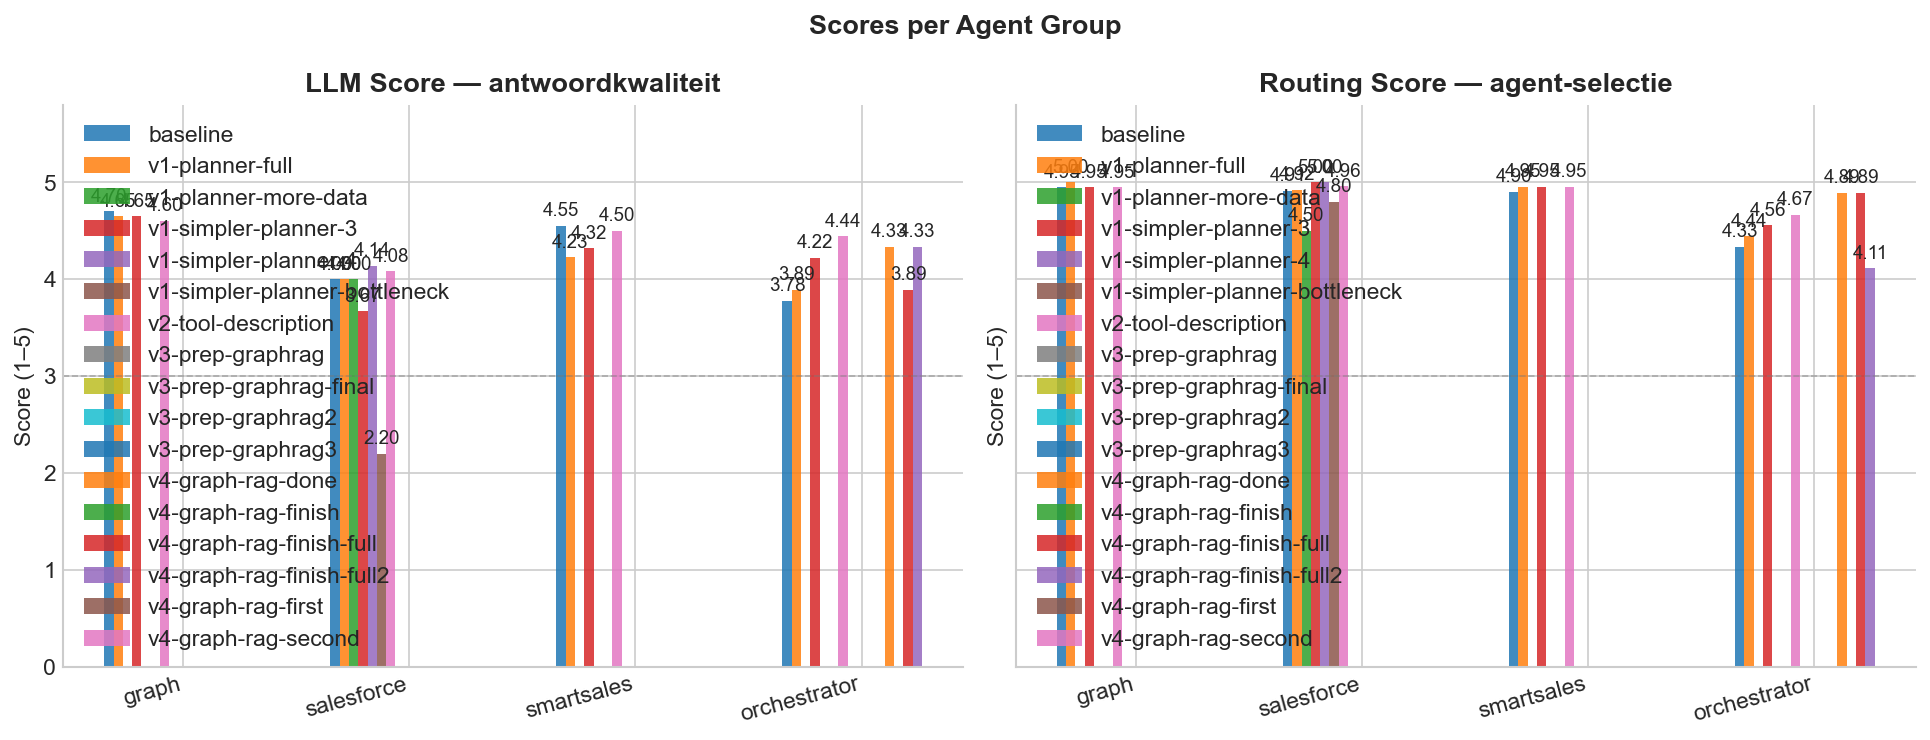

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax_idx, (metric, title) in enumerate([
    ('llm_score',     'LLM Score — antwoordkwaliteit'),
    ('routing_score', 'Routing Score — agent-selectie'),
]):
    ax  = axes[ax_idx]
    x   = np.arange(len(GROUP_ORDER))
    bar_w = 0.7 / max(N_VERSIONS, 1)

    for v_idx, version in enumerate(VERSIONS):
        vdf  = df[df['version'] == version]
        vals = [vdf[vdf['agent_group'] == g][metric].mean() for g in GROUP_ORDER]
        off  = (v_idx - (N_VERSIONS - 1) / 2) * bar_w
        bars = ax.bar(
            x + off, vals, bar_w,
            label=version,
            color=[GROUP_COLORS[g] for g in GROUP_ORDER] if N_VERSIONS == 1 else None,
            alpha=0.85,
        )
        for bar, val in zip(bars, vals):
            if not (val != val):  # not NaN
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.06,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    if N_VERSIONS > 1:
        ax.legend()

plt.suptitle('Scores per Agent Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_per_group.png', bbox_inches='tight')
plt.show()

## 3. Score per categorie (binnen elke agent group)

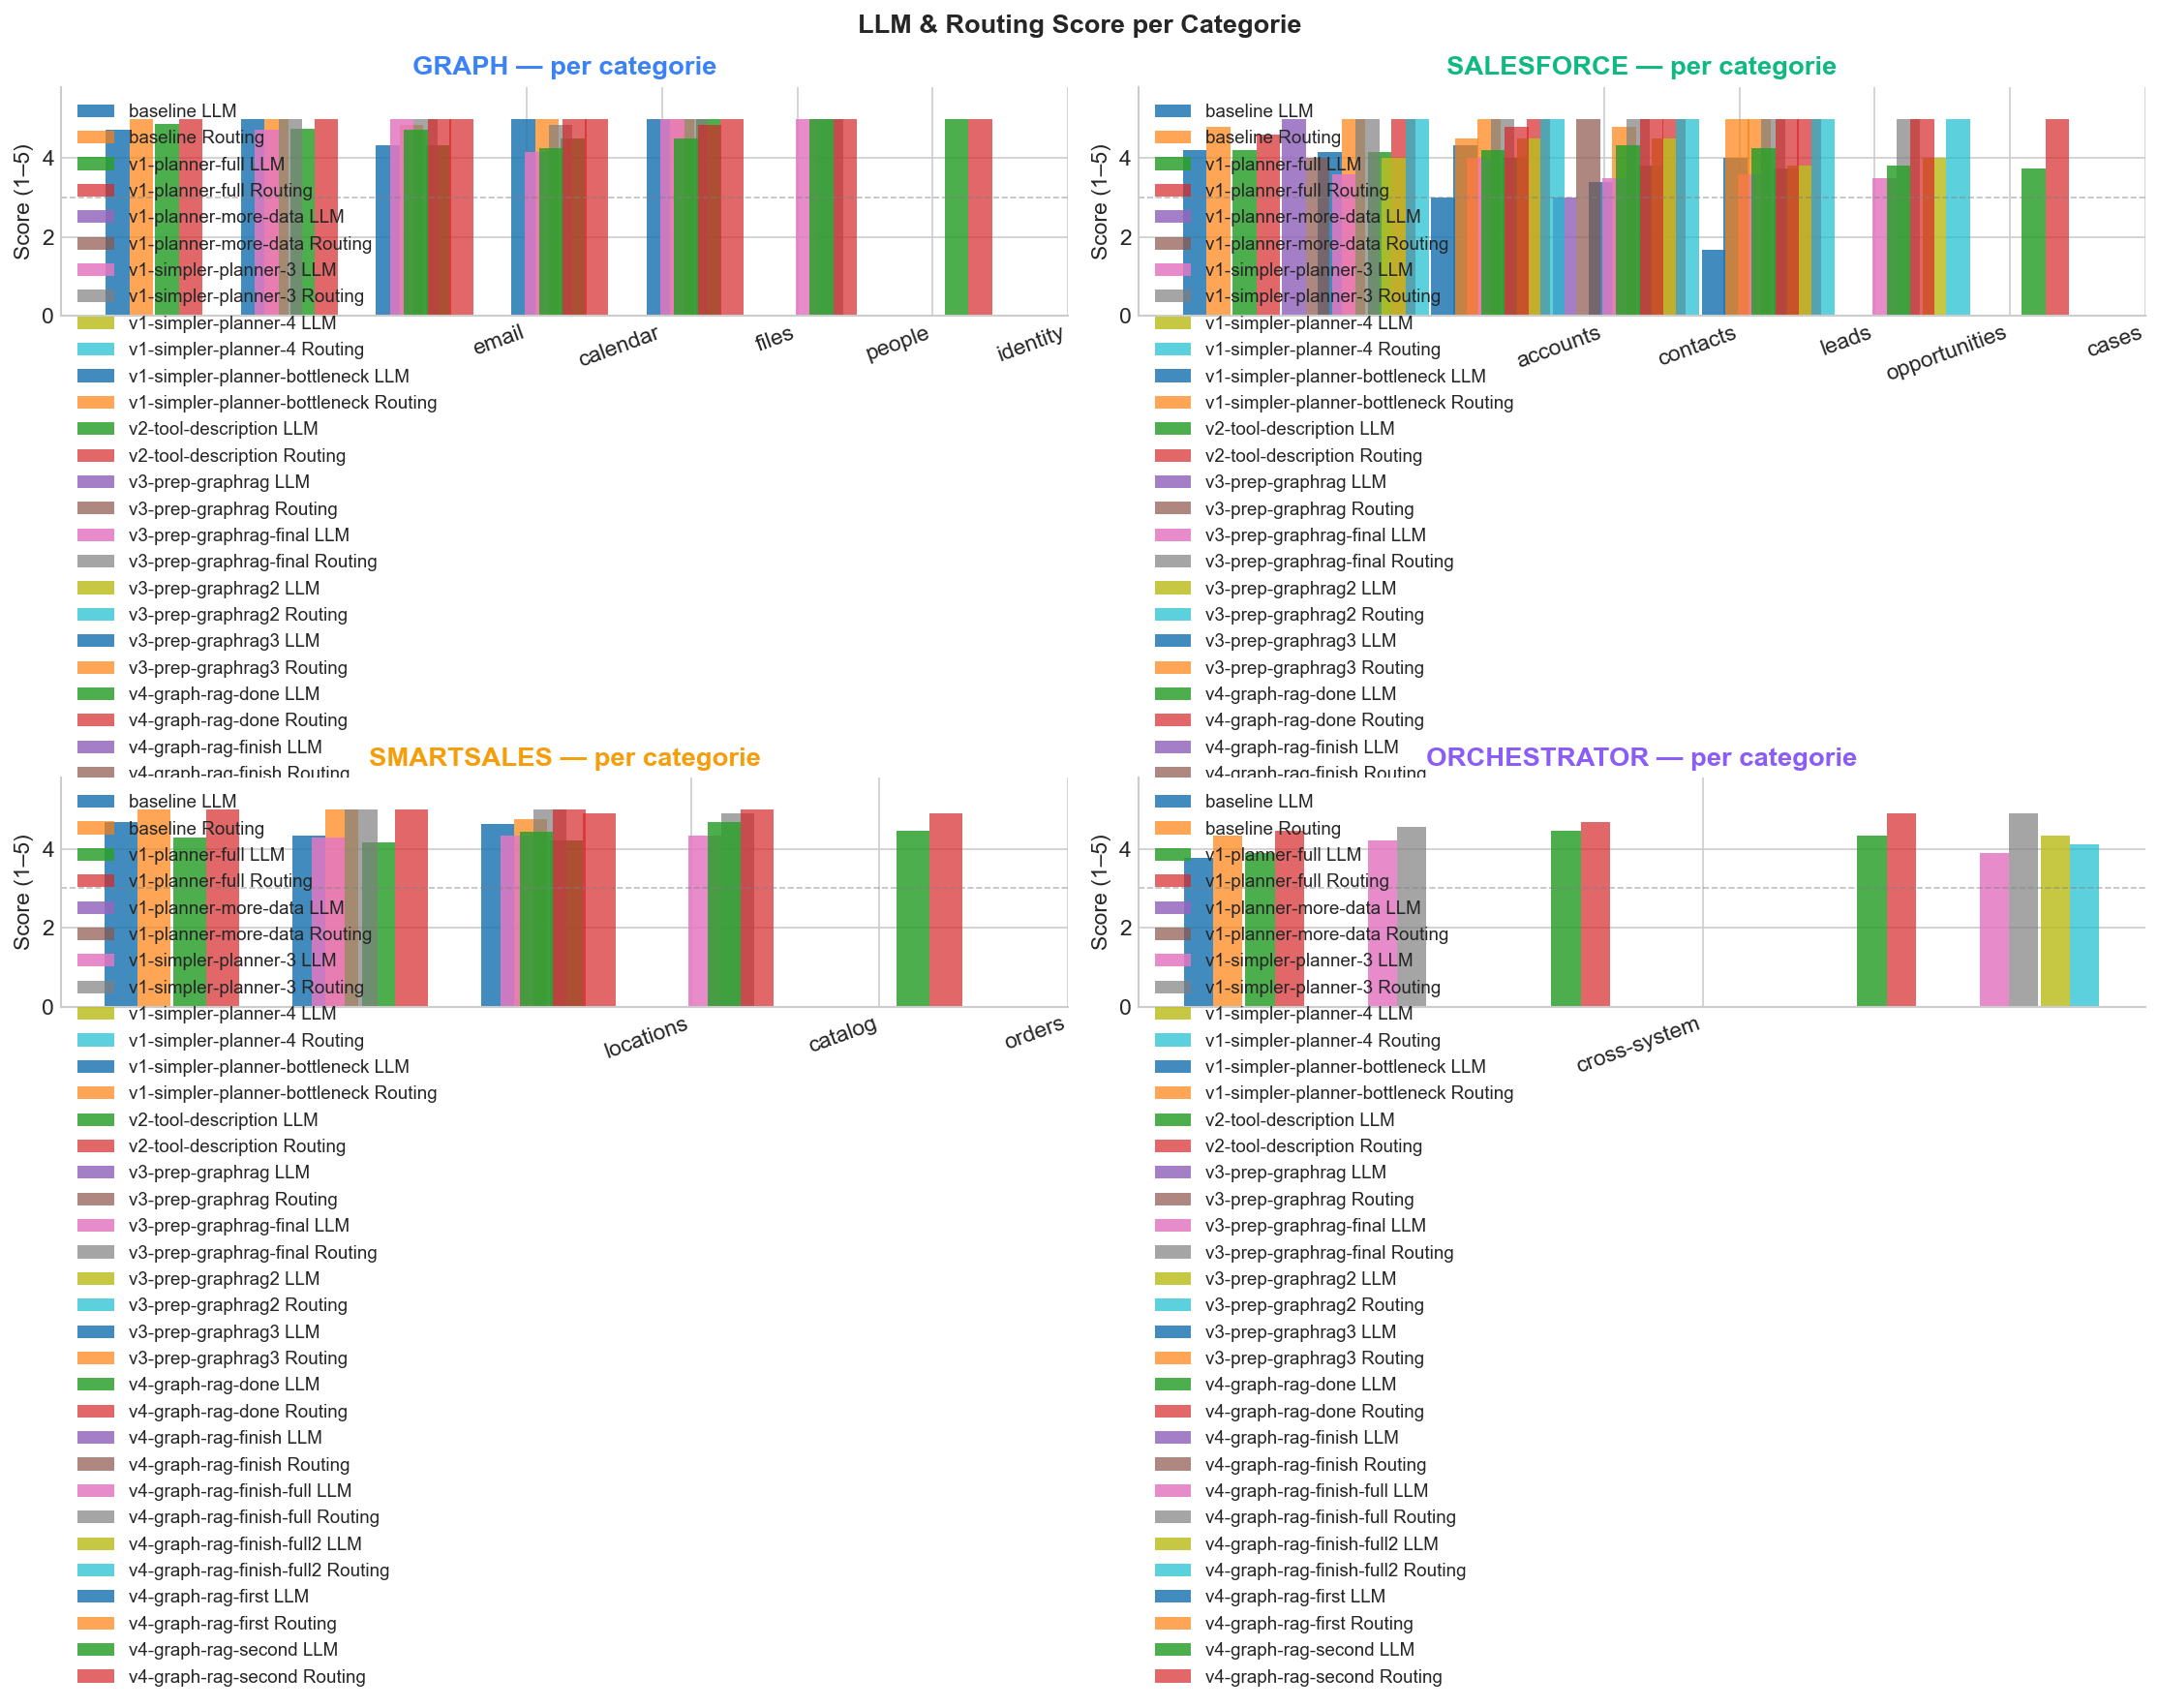

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, group in enumerate(GROUP_ORDER):
    ax   = axes[ax_idx]
    cats = AGENT_GROUPS[group]
    gdf  = df[df['agent_group'] == group]
    x    = np.arange(len(cats))
    w    = 0.35

    if N_VERSIONS == 1:
        version = VERSIONS[0]
        vdf = gdf[gdf['version'] == version]
        llm_vals  = [vdf[vdf['category'] == c]['llm_score'].mean() for c in cats]
        rout_vals = [vdf[vdf['category'] == c]['routing_score'].mean() for c in cats]
        ax.bar(x - w/2, llm_vals,  w, label='LLM score',    color='#3b82f6', alpha=0.85)
        ax.bar(x + w/2, rout_vals, w, label='Routing score', color='#10b981', alpha=0.85)
    else:
        for v_idx, version in enumerate(VERSIONS):
            vdf = gdf[gdf['version'] == version]
            llm_vals  = [vdf[vdf['category'] == c]['llm_score'].mean() for c in cats]
            rout_vals = [vdf[vdf['category'] == c]['routing_score'].mean() for c in cats]
            off = (v_idx - (N_VERSIONS - 1) / 2) * w * 1.05
            ax.bar(x + off - w/4, llm_vals,  w/2, label=f'{version} LLM',     alpha=0.85)
            ax.bar(x + off + w/4, rout_vals, w/2, label=f'{version} Routing', alpha=0.70)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=20, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(f'{group.upper()} — per categorie', fontweight='bold',
                 color=GROUP_COLORS[group])
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle('LLM & Routing Score per Categorie', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_per_category.png', bbox_inches='tight')
plt.show()

## 4. Score per moeilijkheidsgraad

C:\Users\AALB\AppData\Local\Temp\ipykernel_11188\2040873186.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['agent_group', 'difficulty'])[metric]
C:\Users\AALB\AppData\Local\Temp\ipykernel_11188\2040873186.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['agent_group', 'difficulty'])[metric]


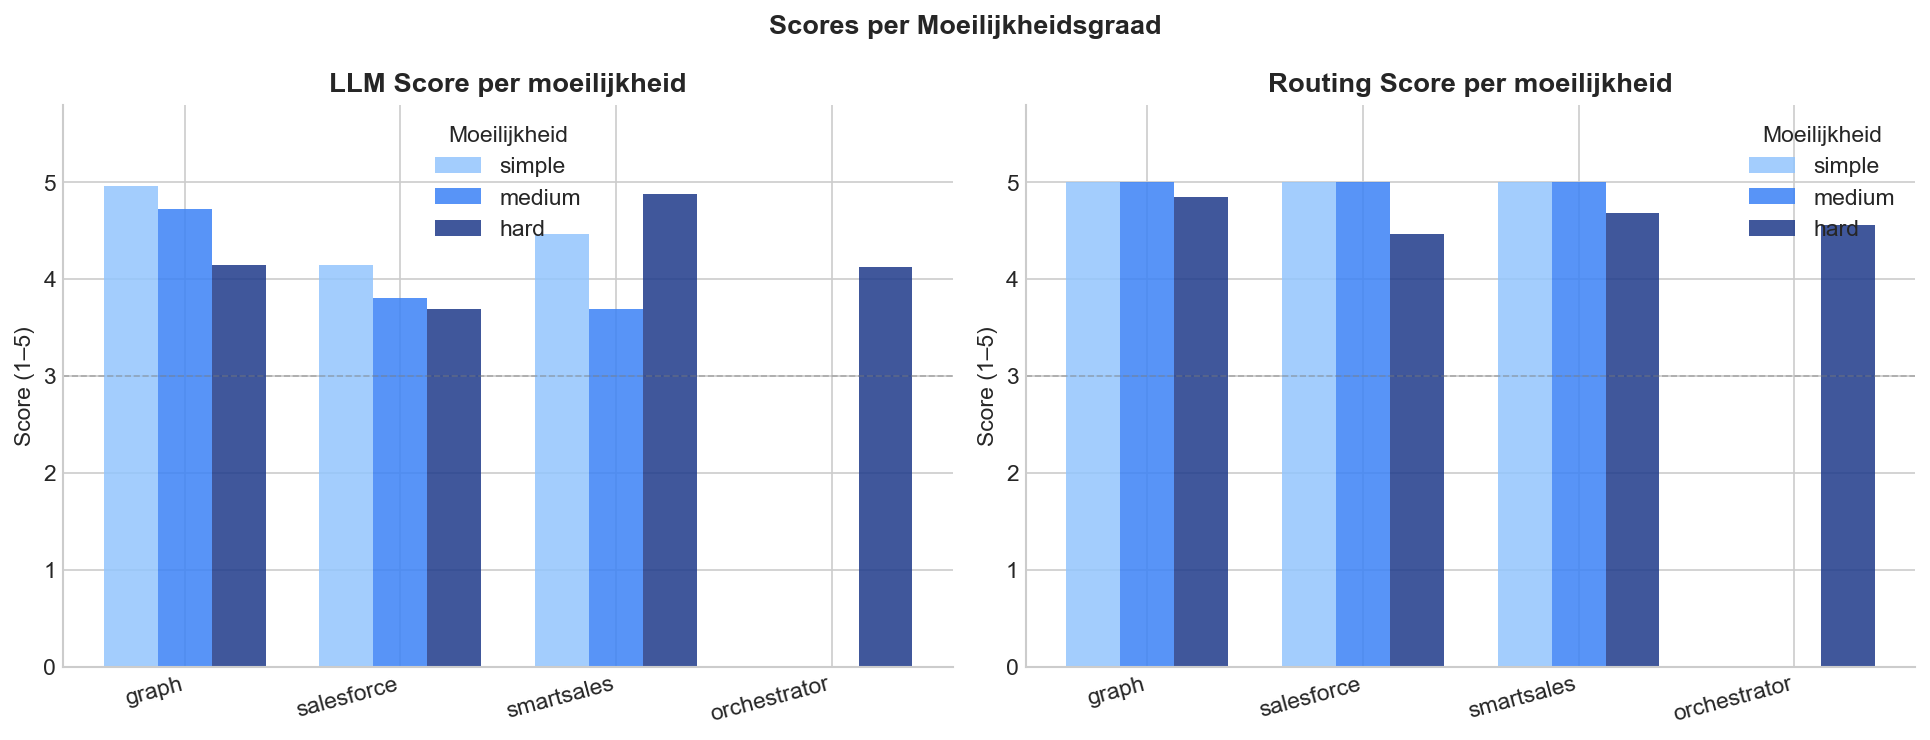

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (metric, title) in enumerate([
    ('llm_score',     'LLM Score per moeilijkheid'),
    ('routing_score', 'Routing Score per moeilijkheid'),
]):
    ax = axes[ax_idx]
    pivot = (
        df.groupby(['agent_group', 'difficulty'])[metric]
        .mean()
        .unstack('difficulty')
        .reindex(GROUP_ORDER)
        .reindex(columns=DIFFICULTY_ORDER)
    )
    x = np.arange(len(GROUP_ORDER))
    w = 0.25
    for d_idx, diff in enumerate(DIFFICULTY_ORDER):
        vals = pivot[diff].values if diff in pivot.columns else [np.nan] * len(GROUP_ORDER)
        off  = (d_idx - 1) * w
        ax.bar(x + off, vals, w, label=diff, color=DIFF_COLORS[diff], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    ax.legend(title='Moeilijkheid')

plt.suptitle('Scores per Moeilijkheidsgraad', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_by_difficulty.png', bbox_inches='tight')
plt.show()

## 5. Latency per agent group

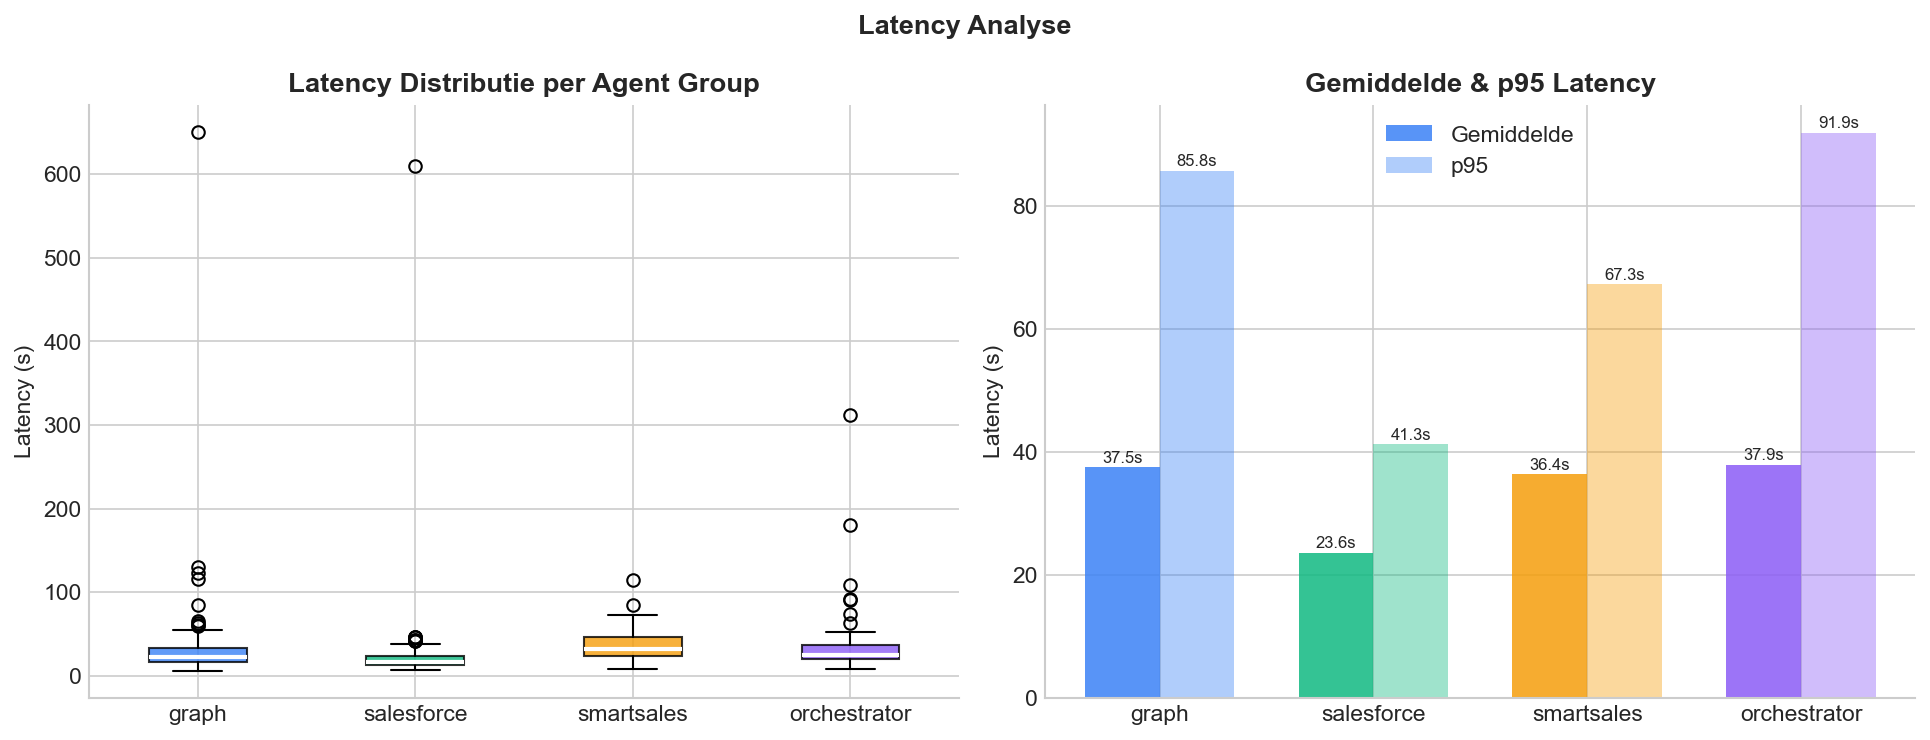

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
ax = axes[0]
box_data = [df[df['agent_group'] == g]['latency_s'].dropna().values for g in GROUP_ORDER]
bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, grp in zip(bp['boxes'], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[grp])
    patch.set_alpha(0.8)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Latency (s)')
ax.set_title('Latency Distributie per Agent Group', fontweight='bold')

# Gemiddelde + p95
ax = axes[1]
x     = np.arange(len(GROUP_ORDER))
w     = 0.35
means = [df[df['agent_group'] == g]['latency_s'].mean() for g in GROUP_ORDER]
p95s  = [df[df['agent_group'] == g]['latency_s'].quantile(0.95) for g in GROUP_ORDER]

b1 = ax.bar(x - w/2, means, w, label='Gemiddelde',
            color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
b2 = ax.bar(x + w/2, p95s,  w, label='p95',
            color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.4)

for bar, val in zip(list(b1) + list(b2), means + p95s):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Latency (s)')
ax.set_title('Gemiddelde & p95 Latency', fontweight='bold')
ax.legend()

plt.suptitle('Latency Analyse', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_latency.png', bbox_inches='tight')
plt.show()

## 6. Token gebruik & geschatte kost

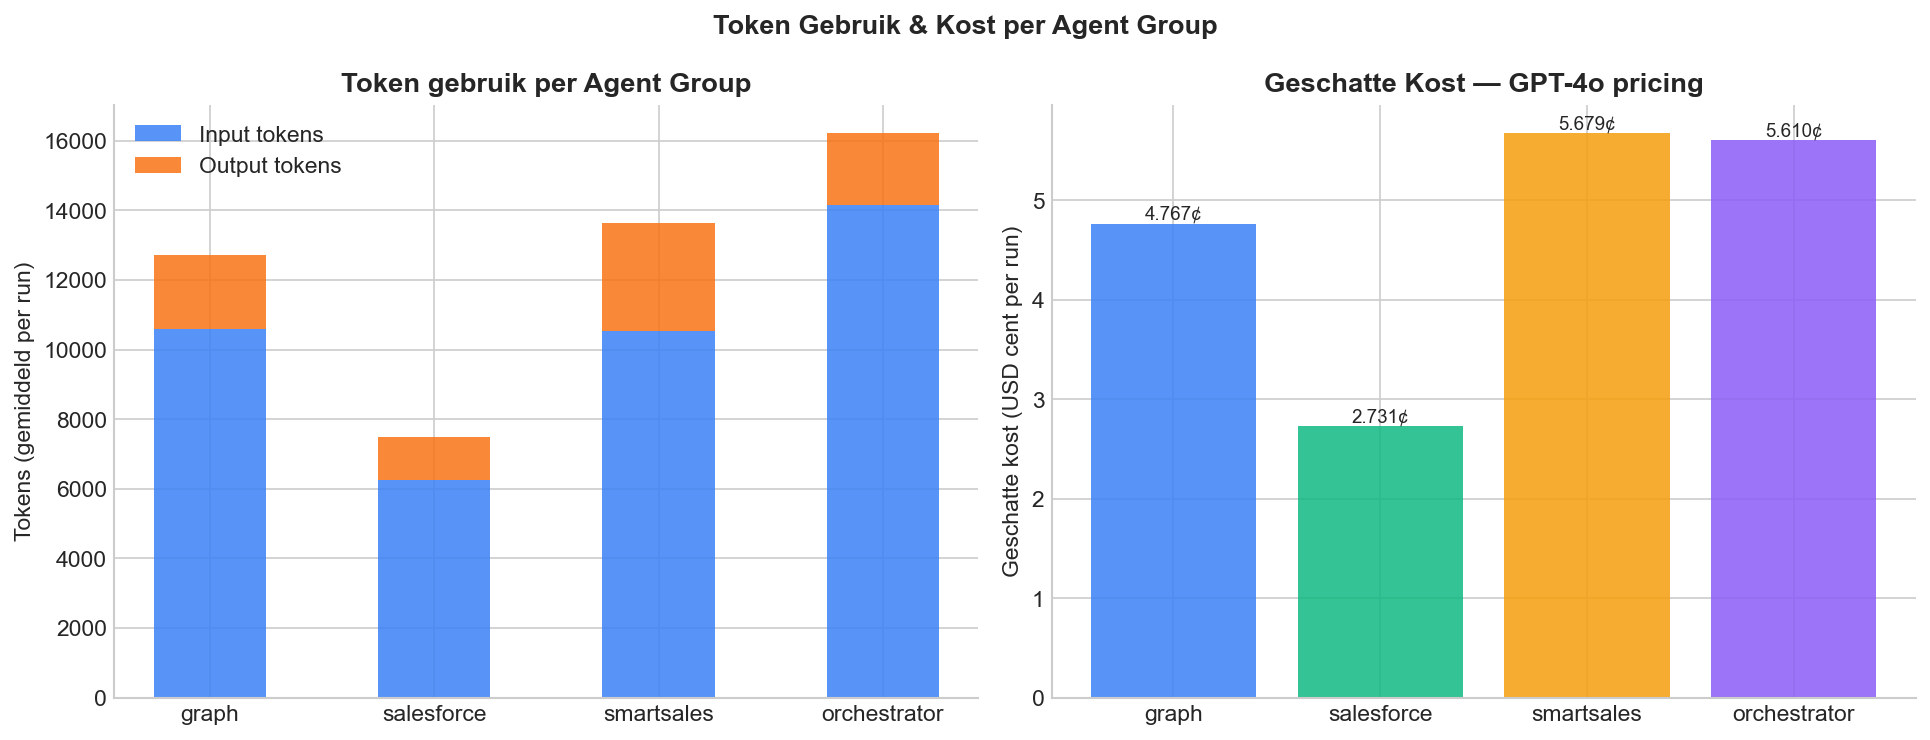

Totale geschatte kost voor deze run(s): $35.2657 USD (3526.57 cent)


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tokens (stacked)
ax = axes[0]
x       = np.arange(len(GROUP_ORDER))
in_tok  = [df[df['agent_group'] == g]['input_tokens'].mean() for g in GROUP_ORDER]
out_tok = [df[df['agent_group'] == g]['output_tokens'].mean() for g in GROUP_ORDER]
ax.bar(x, in_tok,  0.5, label='Input tokens',  color='#3b82f6', alpha=0.85)
ax.bar(x, out_tok, 0.5, bottom=in_tok, label='Output tokens', color='#f97316', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Tokens (gemiddeld per run)')
ax.set_title('Token gebruik per Agent Group', fontweight='bold')
ax.legend()

# Kost (USD cent)
ax = axes[1]
costs = [df[df['agent_group'] == g]['cost_usd'].mean() * 100 for g in GROUP_ORDER]
bars  = ax.bar(x, costs, color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
for bar, val in zip(bars, costs):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}¢', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Geschatte kost (USD cent per run)')
ax.set_title('Geschatte Kost — GPT-4o pricing', fontweight='bold')

plt.suptitle('Token Gebruik & Kost per Agent Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_tokens_cost.png', bbox_inches='tight')
plt.show()

total_cost = df['cost_usd'].sum()
print(f'Totale geschatte kost voor deze run(s): ${total_cost:.4f} USD ({total_cost*100:.2f} cent)')

## 7. Routing Precision & Recall per agent group

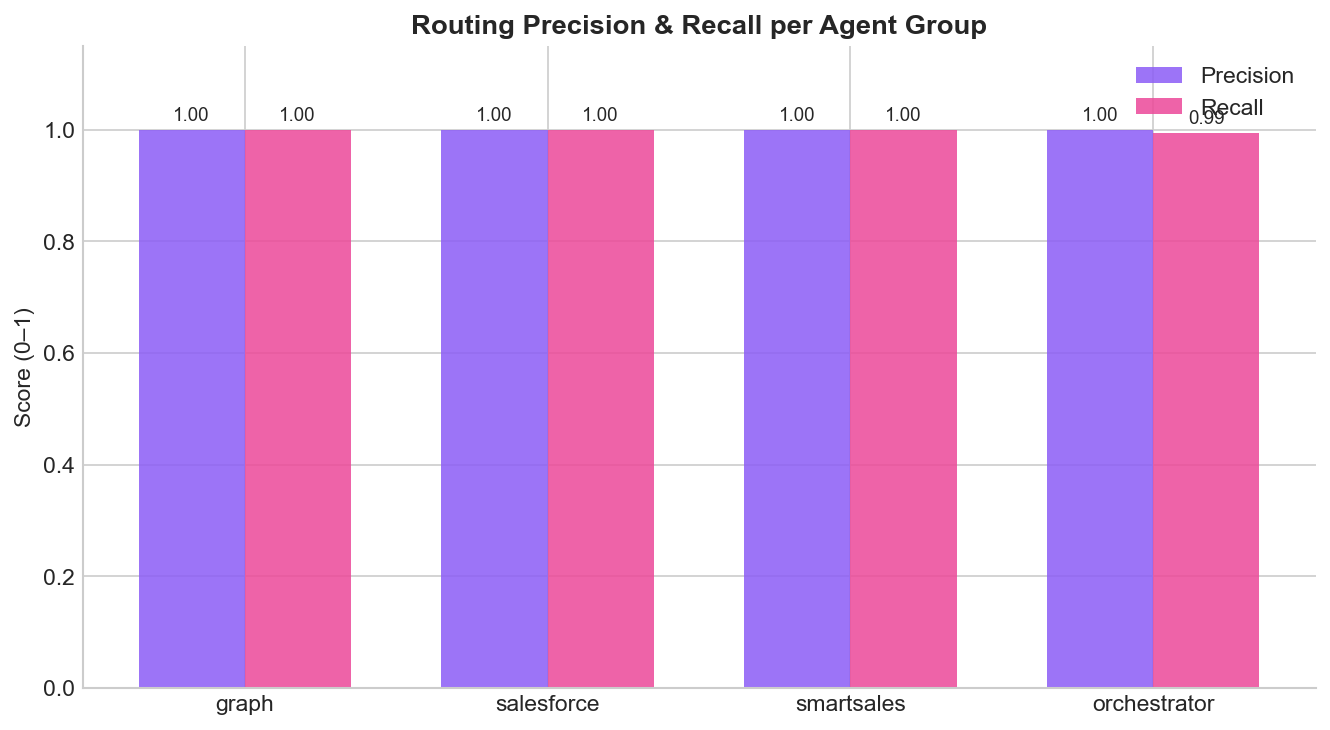

In [117]:
fig, ax = plt.subplots(figsize=(9, 5))
x    = np.arange(len(GROUP_ORDER))
w    = 0.35
prec = [df[df['agent_group'] == g]['routing_precision'].mean() for g in GROUP_ORDER]
rec  = [df[df['agent_group'] == g]['routing_recall'].mean() for g in GROUP_ORDER]

b1 = ax.bar(x - w/2, prec, w, label='Precision', color='#8b5cf6', alpha=0.85)
b2 = ax.bar(x + w/2, rec,  w, label='Recall',    color='#ec4899', alpha=0.85)

for bar, val in zip(list(b1) + list(b2), prec + rec):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score (0–1)')
ax.set_title('Routing Precision & Recall per Agent Group', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_routing_precision_recall.png', bbox_inches='tight')
plt.show()

## 8. Slechtst scorende cases + rationale

In [118]:
LOW_THRESHOLD = 3       # pas aan om meer/minder cases te zien
VERSION       = "v4-graph-rag-done"

# Categoriefilter — zelfde labels als in de samenvattingstabel (cel 1).
# Mogelijke waarden: 'graph', 'salesforce', 'smartsales', 'orchestrator',
#                    'entity-centric1', 'entity-centric2', 'implicit-cross-system', 'onedrive-rag', …
# Laat leeg ([]) voor alle categorieën.
FILTER_CATEGORIES = ['salesforce']

_client = mlflow.MlflowClient()

# _group: zelfde logica als cel 1 — 'unknown' toont echte categorienaam
_vdf_all = df[df['version'] == VERSION].copy()
_vdf_all['_group'] = _vdf_all.apply(
    lambda r: r['agent_group'] if r['agent_group'] != 'unknown' else r['category'], axis=1
)

if _vdf_all.empty:
    print(f"⚠️  Versie '{VERSION}' niet gevonden. Beschikbare versies:")
    print(" ", sorted(df['version'].dropna().unique()))
else:
    _grp_counts = _vdf_all['_group'].value_counts()
    _score_low  = _vdf_all[_vdf_all['llm_score'] <= LOW_THRESHOLD]['_group'].value_counts()
    print(f"Versie: {VERSION}  ({len(_vdf_all)} runs)")
    print(f"{'_group':<24} {'totaal':>7}  {'score<={}'.format(LOW_THRESHOLD):>10}")
    print("─" * 46)
    for grp in _grp_counts.index:
        print(f"  {grp:<22} {_grp_counts[grp]:>7}  {_score_low.get(grp, 0):>10}")
    print()

def _load_response(run_id: str, max_chars: int = 500) -> str:
    try:
        for art in _client.list_artifacts(run_id):
            if art.path.endswith("_response.txt"):
                local = _client.download_artifacts(run_id, art.path)
                with open(local, encoding="utf-8") as f:
                    text = f.read().strip()
                return text[:max_chars] + ("…" if len(text) > max_chars else "")
    except Exception as e:
        return f"[error: {e}]"
    return "[geen response artifact]"

# Filter op _group (dekt zowel agent_group als category)
_base = _vdf_all[_vdf_all['llm_score'] <= LOW_THRESHOLD]
if FILTER_CATEGORIES:
    _base = _base[_base['_group'].isin(FILTER_CATEGORIES)]

low = (
    _base
    .sort_values(['_group', 'llm_score', 'difficulty'])
    .assign(run_id_short=lambda d: d['run_id'].str[:8])
    .reset_index(drop=True)
)

low['response'] = low['run_id'].apply(_load_response)

low = low[['run_name', 'run_id_short', 'version', '_group', 'category', 'difficulty',
           'llm_score', 'routing_score', 'query', 'response', 'llm_rationale']]

_cat_label = f" | categorie: {', '.join(FILTER_CATEGORIES)}" if FILTER_CATEGORIES else ""
print(f'Cases met llm_score <= {LOW_THRESHOLD}{_cat_label}: {len(low)} / {len(_vdf_all)} (versie {VERSION})')

pd.set_option('display.max_colwidth', 300)
pd.set_option('display.max_rows', 60)

if low.empty:
    print("Geen cases gevonden — pas VERSION, LOW_THRESHOLD of FILTER_CATEGORIES aan.")
else:
    display(
        low.style
        .map(
            lambda v: 'background-color:#fee2e2' if v == 1 else
                      ('background-color:#fef9c3' if v == 2 else ''),
            subset=['llm_score', 'routing_score'],
        )
        .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
        .set_caption(f'Lage-score cases (llm_score <= {LOW_THRESHOLD}){_cat_label}')
    )

# ── Volledige run_ids ─────────────────────────────────────────────────────────
if not low.empty:
    print('\n── Run IDs ──')
    _ids = _base.sort_values(['_group', 'llm_score'])[['run_name', 'run_id']].reset_index(drop=True)
    for _, row in _ids.iterrows():
        name = row.get('run_name') or '?'
        print(f"  {name:<35}  {row['run_id']}")

Versie: v4-graph-rag-done  (120 runs)
_group                    totaal    score<=3
──────────────────────────────────────────────
  smartsales                  25           3
  salesforce                  20           2
  graph                       20           2
  onedrive-rag                17           3
  entity-centric1             11           5
  entity-centric2             10           5
  orchestrator                 9           1
  implicit-cross-system        8           6



Cases met llm_score <= 3 | categorie: salesforce: 2 / 120 (versie v4-graph-rag-done)


,run_name,run_id_short,version,_group,category,difficulty,llm_score,routing_score,query,response,llm_rationale
0,tc02_salesforce_medium,4343d1ba,v4-graph-rag-done,salesforce,salesforce,medium,3.000000,5.000000,Show me 5 closed Salesforce cases including their close date and description.,"Planning query... Plan: 1 stap(pen) ️Executing (salesforce)... Synthesizing... Here are 5 closed Salesforce cases, including their close dates and descriptions: 1. **Case Number**: 00001002 - **Subject**: Sample Case 3: Cannot track our order. - **Closed Date**: 22 November 2024 - **Description**: N/A 2. **Case Number**: 00001008 - **Subject**: Problème accès site - **Closed Date**: 22 November 2024 - **Description**: Test 3. **Case Number**: 00001012 - **Subject**: (Gmai…","The response provides a list of 5 closed Salesforce cases, but the descriptions for some cases are marked as 'N/A' or are very brief, which limits the completeness of the information."
1,tc13_salesforce_medium,1611ce23,v4-graph-rag-done,salesforce,salesforce,medium,3.000000,5.000000,Show me the most recently created Salesforce contacts.,Planning query... Plan: 1 stap(pen) ️Executing (salesforce)... Synthesizing... Here are the most recently created Salesforce contacts: - **Arne Albrecht** - Email: a.albrecht@easi.net - Account Name: EASI - ID: 003KI000009uzRbYAI - **Dorian Feaux** - Email: d.feaux@easi.net - Account Name: EASI - ID: 003KI000009uzRRYAY - **Marc Supplier** - Email: marc.supplier@supplier1.be - Account Name: supplier1 - ID: 003KI000009uzQsYAI - **mister maestro** - Email: mist.maestro@gmail…,"The response provides a list of Salesforce contacts with their names and emails, which is mostly correct. However, it lacks the creation dates of the contacts and includes additional information that was not requested, such as Account Name and ID."



── Run IDs ──
  tc02_salesforce_medium               4343d1ba9aa34fd39f712ec8e4d30d57
  tc13_salesforce_medium               1611ce23941a406f87a2f31e4ec9412c


In [119]:
# for run_id in [
# "7d0454fabf794c3da5ad1de5b6e1d107",
# "15610fb5e50a49168b0242a670b29272",
# "dca5ddbde63b450d9002eb33d2948278",
# "bfa59f6b14084fedb936624b6a3523f1",

# ]:

#   mlflow.delete_run(run_id)

## 9. Cross-system / Orchestrator deep dive

Cross-system cases: 63


,version,difficulty,llm_score,routing_score,plan_steps,parallel_ratio,latency_s,total_tokens
0,v4-graph-rag-finish-full2,hard,1.0,2.0,3.0,0.333,311.390,15081.0
1,v4-graph-rag-finish-full,hard,2.0,5.0,2.0,0.500,24.054,13672.0
2,v4-graph-rag-finish-full,hard,3.0,5.0,2.0,0.500,92.072,34006.0
3,v4-graph-rag-done,hard,3.0,4.0,3.0,1.000,21.864,11145.0
4,baseline,hard,3.0,5.0,2.0,0.500,18.690,6681.0
...,...,...,...,...,...,...,...,...
58,v2-tool-description,hard,5.0,5.0,2.0,0.500,14.862,6699.0
59,v1-planner-full,hard,5.0,4.0,2.0,0.500,15.313,10723.0
60,v2-tool-description,hard,5.0,5.0,2.0,0.500,23.368,15806.0
61,v1-simpler-planner-3,hard,5.0,4.0,2.0,0.500,36.520,14855.0


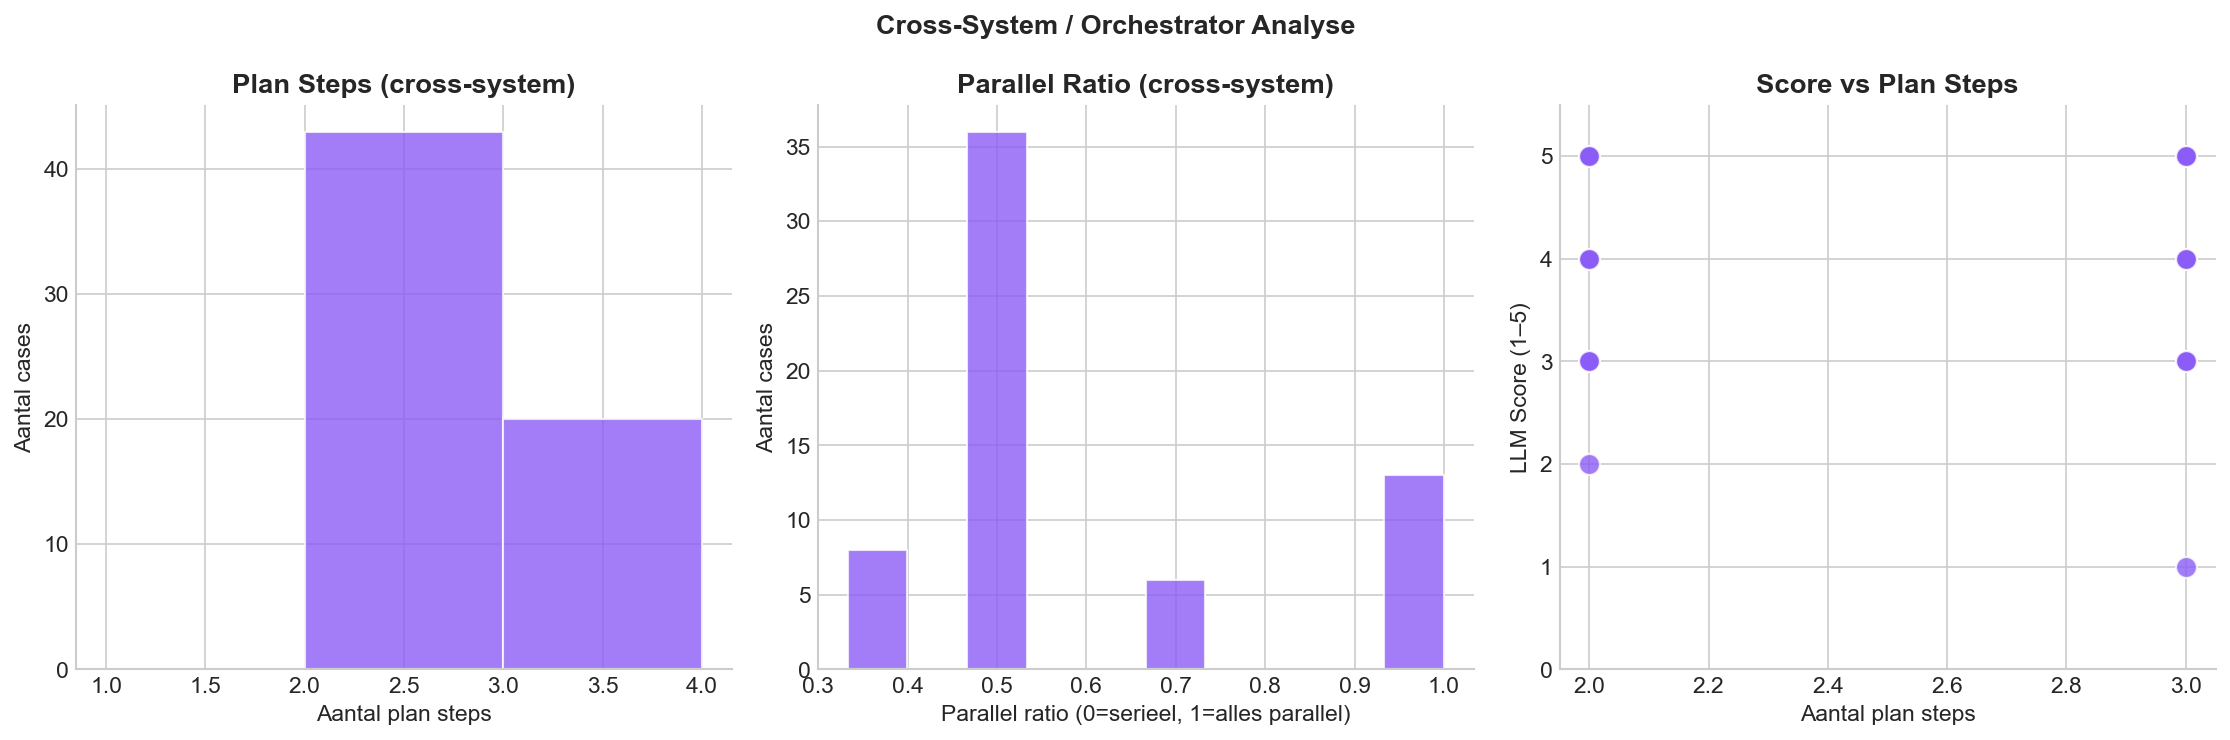

In [120]:
cross = df[df['agent_group'] == 'orchestrator'].copy()
print(f'Cross-system cases: {len(cross)}')
display(cross[['version', 'difficulty', 'llm_score', 'routing_score',
               'plan_steps', 'parallel_ratio', 'latency_s', 'total_tokens']]
        .sort_values('llm_score').reset_index(drop=True))

if len(cross) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Verdeling plan steps
    ax = axes[0]
    bins = range(1, int(cross['plan_steps'].max() + 2)) if cross['plan_steps'].notna().any() else range(1, 6)
    ax.hist(cross['plan_steps'].dropna(), bins=bins, color='#8b5cf6', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Aantal plan steps')
    ax.set_ylabel('Aantal cases')
    ax.set_title('Plan Steps (cross-system)', fontweight='bold')

    # Parallel ratio
    ax = axes[1]
    ax.hist(cross['parallel_ratio'].dropna(), bins=10, color='#8b5cf6', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Parallel ratio (0=serieel, 1=alles parallel)')
    ax.set_ylabel('Aantal cases')
    ax.set_title('Parallel Ratio (cross-system)', fontweight='bold')

    # Score vs plan steps scatter
    ax = axes[2]
    ax.scatter(cross['plan_steps'], cross['llm_score'],
               c='#8b5cf6', s=100, alpha=0.8, edgecolors='white', zorder=3)
    ax.set_xlabel('Aantal plan steps')
    ax.set_ylabel('LLM Score (1–5)')
    ax.set_ylim(0, 5.5)
    ax.set_title('Score vs Plan Steps', fontweight='bold')

    plt.suptitle('Cross-System / Orchestrator Analyse', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_cross_system.png', bbox_inches='tight')
    plt.show()

## 10. Versievergelijking (baseline vs v1 …)

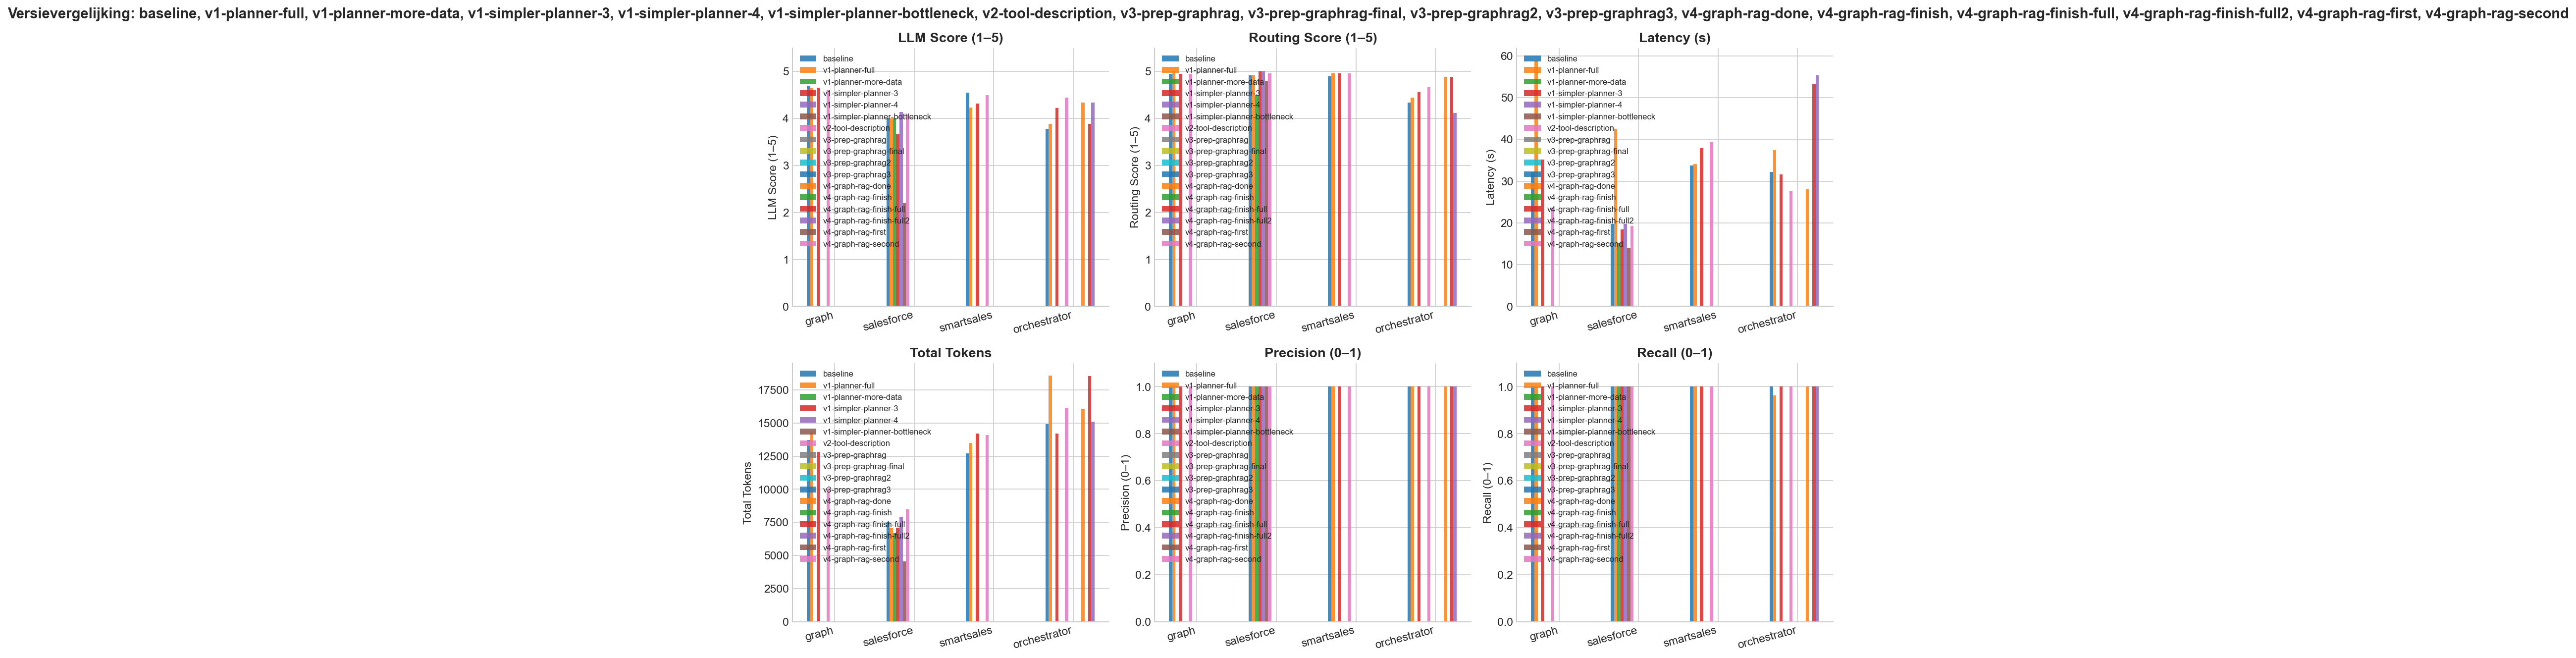


── Delta (v4-graph-rag-second − baseline) per agent group ──

llm_score:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN

routing_score:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN

latency_s:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN

total_tokens:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN


In [121]:
if N_VERSIONS < 2:
    print(f'Slechts 1 versie gevonden ({VERSIONS[0]}). Run mlflow_eval.py met --version v1 voor vergelijking.')
else:
    metrics_to_compare = [
        ('llm_score',         'LLM Score (1–5)',    (0, 5.5)),
        ('routing_score',     'Routing Score (1–5)', (0, 5.5)),
        ('latency_s',         'Latency (s)',          None),
        ('total_tokens',      'Total Tokens',         None),
        ('routing_precision', 'Precision (0–1)',      (0, 1.1)),
        ('routing_recall',    'Recall (0–1)',         (0, 1.1)),
    ]

    n_cols = 3
    n_rows = (len(metrics_to_compare) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4.5))
    axes = axes.flatten()

    for ax_idx, (metric, label, ylim) in enumerate(metrics_to_compare):
        ax    = axes[ax_idx]
        x     = np.arange(len(GROUP_ORDER))
        bar_w = 0.7 / N_VERSIONS
        for v_idx, version in enumerate(VERSIONS):
            vdf  = df[df['version'] == version]
            vals = [vdf[vdf['agent_group'] == g][metric].mean() for g in GROUP_ORDER]
            off  = (v_idx - (N_VERSIONS - 1) / 2) * bar_w
            ax.bar(x + off, vals, bar_w, label=version, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
        ax.set_ylabel(label)
        ax.set_title(label, fontweight='bold')
        if ylim:
            ax.set_ylim(*ylim)
        ax.legend(fontsize=8)

    for i in range(len(metrics_to_compare), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Versievergelijking: {", ".join(VERSIONS)}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('plot_version_comparison.png', bbox_inches='tight')
    plt.show()

    # Delta tabel
    print(f'\n── Delta ({VERSIONS[-1]} − {VERSIONS[0]}) per agent group ──')
    for metric in ['llm_score', 'routing_score', 'latency_s', 'total_tokens']:
        base  = df[df['version'] == VERSIONS[0]].groupby('agent_group')[metric].mean()
        comp  = df[df['version'] == VERSIONS[-1]].groupby('agent_group')[metric].mean()
        delta = (comp - base).reindex(GROUP_ORDER).round(3)
        print(f'\n{metric}:')
        print(delta.to_string())

## 11. Prompt coverage — welke prompts zijn al gerund?

In [122]:
import json as _json
import os as _os
from collections import Counter as _Counter

# category = ["entity-centric1", "entity-centric2", "implicit-cross-system"]
category = [] 
# Zet op None om alle categorieën te checken
# category = None

# Pad naar prompts-bestand (afgeleid van TRACKING_URI)
_project_root = _os.path.dirname(TRACKING_URI.replace('sqlite:///', ''))
_prompts_file = _os.path.join(_project_root, 'eval', 'prompts', 'all_prompts.json')
if not _os.path.exists(_prompts_file):
    _prompts_file = 'eval/prompts/all_prompts.json'

with open(_prompts_file, encoding='utf-8') as _f:
    _all_prompts = _json.load(_f)

print(f'Prompts-bestand : {_prompts_file}')
print(f'Totaal in bestand: {len(_all_prompts)} prompts')

_fp = lambda text: text.strip()[:200]
_expected = {_fp(p['text']): p for p in _all_prompts}

if category:
    _expected = {k: v for k, v in _expected.items() if v.get('category') in category}
    print(f'Categorie filter: {category}')
print(f'Totaal verwacht : {len(_expected)} prompts')

# CHECK_VERSION = VERSIONS[0]  # aanpassen naar bijv. 'v1'
# CHECK_VERSION = VERSIONS[-1]
CHECK_VERSION =  "v4-graph-rag-done" 
print(f'Versie checken  : {CHECK_VERSION}')

_vdf = df[df['version'] == CHECK_VERSION].copy()
_run_fps = set()
if 'query' in _vdf.columns:
    _run_fps = {_fp(str(q)) for q in _vdf['query'].dropna()}

_missing, _found = [], []
for _key, _p in _expected.items():
    _matched = any(_key.startswith(_r) or _r.startswith(_key) for _r in _run_fps)
    (_found if _matched else _missing).append(_p)

print(f'Gerund          : {len(_found)}')
print(f'Ontbrekend      : {len(_missing)}')
print()

if not _missing:
    print('Alle prompts zijn gerund!')
else:
    _miss_df = pd.DataFrame(_missing)[['category', 'difficulty', 'text']].copy()
    _miss_df['text'] = _miss_df['text'].str[:100]
    _miss_df = _miss_df.sort_values(['category', 'difficulty']).reset_index(drop=True)
    display(_miss_df)
    print()
    print('=== Commando per ontbrekende categorie ===')
    for _cat, _n in sorted(_Counter(p['category'] for p in _missing).items()):
        print(f'  python eval/mlflow_eval.py --version {CHECK_VERSION} --category {_cat}  # {_n} prompt(s)')

if 'query' in _vdf.columns:
    _dup_counts = _vdf['query'].dropna().apply(_fp).value_counts()
    _dupes = _dup_counts[_dup_counts > 1]
    print()
    if not _dupes.empty:
        print('=== Dubbele runs ===')
        for _key, _cnt in _dupes.items():
            _rows = _vdf[_vdf['query'].apply(lambda q: _fp(str(q))) == _key]
            _ids  = ', '.join(_rows['run_id'].str[:8].tolist())
            print(f'  [{_cnt}x] {_key[:80]}')
            print(f'         run_ids: {_ids}')
    else:
        print('Geen dubbele runs.')

Prompts-bestand : C:/Users/AALB/Desktop/mp/graph/graphxmaf\eval\prompts\all_prompts.json
Totaal in bestand: 122 prompts
Totaal verwacht : 122 prompts
Versie checken  : v4-graph-rag-done
Gerund          : 113
Ontbrekend      : 9



,category,difficulty,text
0,entity-centric1,hard,Is there anything I should follow up on today?
1,entity-centric2,hard,What locations do we have and what deals are linked to them?
2,graph-extra,medium,List my Microsoft 365 contacts and include their phone numbers.
3,graph-extra,simple,Show me my Microsoft 365 contacts.
4,implicit-cross-system,hard,Which of my recent email senders also have an active deal with us?
5,implicit-cross-system,hard,Are there companies in my upcoming calendar that we have no record of?
6,implicit-cross-system,hard,Which companies that emailed me recently do not seem to have a location registered with us?
7,salesforce,medium,"Find Salesforce accounts in Belgium, including their billing address."
8,salesforce,simple,Show me Salesforce accounts with their phone numbers.



=== Commando per ontbrekende categorie ===
  python eval/mlflow_eval.py --version v4-graph-rag-done --category entity-centric1  # 1 prompt(s)
  python eval/mlflow_eval.py --version v4-graph-rag-done --category entity-centric2  # 1 prompt(s)
  python eval/mlflow_eval.py --version v4-graph-rag-done --category graph-extra  # 2 prompt(s)
  python eval/mlflow_eval.py --version v4-graph-rag-done --category implicit-cross-system  # 3 prompt(s)
  python eval/mlflow_eval.py --version v4-graph-rag-done --category salesforce  # 2 prompt(s)

=== Dubbele runs ===
  [2x] For the company behind my most recent open support case, give me a full 360 view
         run_ids: 7d344034, 29f251b8
  [2x] Give me a 360° view of the most recent email sender.
         run_ids: e9829e5d, 48b96497
  [2x] What fields can be displayed for SmartSales catalog items?
         run_ids: 385c2da0, d5d59008
  [2x] List all SmartSales order approbation statuses.
         run_ids: be795fbd, 23143f94
  [2x] Prepare me for my 

## 12. Dubbele runs vergelijken — welke bewaren / verwijderen?

In [123]:
# Plak hier de run_ids (8-char) uit cel 11 — alle duplicates bij elkaar
DUPLICATE_RUN_IDS = [
    "737f0dfa", "048c9a0a", "bf538265" 
]

# ── Match korte IDs naar volledige run_ids ────────────────────────────────────
_short_to_full = {rid[:8]: rid for rid in df['run_id']}
_full_ids = list({_short_to_full[s] for s in DUPLICATE_RUN_IDS if s in _short_to_full})

COLS = ['run_name', 'run_id', 'category', 'difficulty',
        'llm_score', 'routing_score', 'latency_s', 'total_tokens', 'success', 'llm_rationale']
_show_cols = [c for c in COLS if c in df.columns]

_dup_df = (
    df[df['run_id'].isin(_full_ids)]
    .sort_values(['category', 'difficulty', 'llm_score'], ascending=[True, True, False])
    [_show_cols]
    .reset_index(drop=True)
)

pd.set_option('display.max_colwidth', 100)
print(f'{len(_dup_df)} runs gevonden\n')

display(
    _dup_df.style
    .map(
        lambda v: 'background-color:#d1fae5' if isinstance(v, float) and v >= 4 else
                  ('background-color:#fee2e2' if isinstance(v, float) and v <= 2 else ''),
        subset=[c for c in ['llm_score', 'routing_score'] if c in _dup_df.columns],
    )
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_caption('Groen = score >= 4 | Rood = score <= 2')
)

# ── Automatisch beste run per prompt selecteren ───────────────────────────────
# Keuze: hoogste llm_score, bij gelijkspel laagste latency
_keep, _delete = [], []
if 'query' in df.columns:
    _dup_full = df[df['run_id'].isin(_full_ids)].copy()
    _dup_full['_fp'] = _dup_full['query'].fillna('').apply(lambda t: t.strip()[:200])

    print('=== Aanbevolen bewaren / verwijderen ===')
    for _fp_key, _grp in _dup_full.groupby('_fp'):
        _grp_sorted = _grp.sort_values(
            ['llm_score', 'routing_score', 'latency_s'],
            ascending=[False, False, True],
        )
        _best = _grp_sorted.iloc[0]
        _rest = _grp_sorted.iloc[1:]
        _keep.append(_best['run_id'])
        _delete.extend(_rest['run_id'].tolist())
        _label = (_best.get('run_name') or _best['run_id'][:8])
        print(f'  KEEP  {_label:<38} llm={_best["llm_score"]}/5  lat={_best["latency_s"]:.1f}s')
        for _, _r in _rest.iterrows():
            _rl = (_r.get('run_name') or _r['run_id'][:8])
            print(f'  DEL   {_rl:<38} llm={_r["llm_score"]}/5  lat={_r["latency_s"]:.1f}s')

    print(f'\n=== Verwijder {len(_delete)} run(s) — uncomment en run ===')
    print('# mlflow.set_tracking_uri(TRACKING_URI)')
    print('# for run_id in [')
    for _rid in _delete:
        _rname = (df[df['run_id'] == _rid]['run_name'].iloc[0]
                  if 'run_name' in df.columns else '')
        print(f'#     "{_rid}",  # {_rname}')
    print('# ]:')
    print('#     mlflow.delete_run(run_id)')

1 runs gevonden



,run_name,run_id,category,difficulty,llm_score,routing_score,latency_s,total_tokens,success,llm_rationale
0,tc00_leads_medium,737f0dfa002a4536ad9987cefcb3e048,leads,medium,4.000000,5.000000,13.061000,5192.000000,1.000000,"The response correctly lists leads from the Technology industry, providing the required details, but it does not include any leads from the Software industry, which was part of the request."


=== Aanbevolen bewaren / verwijderen ===
  KEEP  tc00_leads_medium                      llm=4.0/5  lat=13.1s

=== Verwijder 0 run(s) — uncomment en run ===
# mlflow.set_tracking_uri(TRACKING_URI)
# for run_id in [
# ]:
#     mlflow.delete_run(run_id)


In [124]:
# mlflow.set_tracking_uri(TRACKING_URI)
# for run_id in [
#     "bf5382657a054cd8a3868c5c83752078",
#     "048c9a0a3fcc4a049cd8cd75b23b5bf0"

# ]:
#     mlflow.delete_run(run_id)

## 13. Versies verwijderen

In [125]:
# Beschikbare versies in de database
print("Beschikbare versies:")
for v in sorted(df["version"].dropna().unique()):
    n = (df["version"] == v).sum()
    print(f"  {v!r:40s}  ({n} runs)")

# ── Stel hier in welke versies je wilt verwijderen ────────────────────────────
VERSIONS_TO_DELETE = [
    "v1-simpler-planner",
    "v1-simpler-planner-new",
]

if not VERSIONS_TO_DELETE:
    print("Geen versies geselecteerd — vul VERSIONS_TO_DELETE in en run opnieuw.")
else:
    # Zoek alle child-runs voor de geselecteerde versies
    _child_ids = df[df["version"].isin(VERSIONS_TO_DELETE)]["run_id"].tolist()

    # Zoek de bijbehorende parent-runs
    _all_runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        output_format="pandas",
    )
    _parent_col = "tags.mlflow.parentRunId"
    _child_run_ids_set = set(_child_ids)

    # Parent run = geen parentRunId tag (of leeg)
    _is_parent = _all_runs.get(_parent_col, pd.Series("", index=_all_runs.index)).fillna("") == ""
    _parent_runs = _all_runs[_is_parent]
    _child_runs  = _all_runs[~_is_parent]

    # Behoud alleen parents waarvan ALLE children worden verwijderd
    _parent_ids_to_delete = []
    for _pid in _parent_runs["run_id"]:
        _kids = _child_runs[
            _child_runs.get(_parent_col, pd.Series("", index=_child_runs.index)).fillna("") == _pid
        ]["run_id"].tolist()
        if _kids and all(c in _child_run_ids_set for c in _kids):
            _parent_ids_to_delete.append(_pid)

    _total = len(_child_ids) + len(_parent_ids_to_delete)
    print(f"Te verwijderen: {len(_child_ids)} child-runs + {len(_parent_ids_to_delete)} parent-runs = {_total} runs")
    for _v in VERSIONS_TO_DELETE:
        _n = (df["version"] == _v).sum()
        print(f"  {_v!r}: {_n} child-runs")

    print("⚠️  Verwijderen is onomkeerbaar (soft-delete in MLflow).")
    print("Zet DRY_RUN = False om echt te verwijderen.")

    DRY_RUN = True # ← zet op False om echt te verwijderen

    mlflow.set_tracking_uri(TRACKING_URI)
    _deleted = 0
    for _rid in _child_ids + _parent_ids_to_delete:
        if not DRY_RUN:
            mlflow.delete_run(_rid)
        _deleted += 1

    if DRY_RUN:
        print(f"[DRY RUN] Zou {_deleted} runs verwijderen — zet DRY_RUN = False om te bevestigen.")
    else:
        print(f"Verwijderd: {_deleted} runs. Herlaad cel 3 (data laden) om df te verversen.")


Beschikbare versies:
  'baseline'                                (72 runs)
  'v1-planner-full'                         (76 runs)
  'v1-planner-more-data'                    (2 runs)
  'v1-simpler-planner-3'                    (75 runs)
  'v1-simpler-planner-4'                    (22 runs)
  'v1-simpler-planner-bottleneck'           (7 runs)
  'v2-tool-description'                     (77 runs)
  'v3-prep-graphrag'                        (24 runs)
  'v3-prep-graphrag-final'                  (38 runs)
  'v3-prep-graphrag2'                       (10 runs)
  'v3-prep-graphrag3'                       (10 runs)
  'v4-graph-rag-done'                       (120 runs)
  'v4-graph-rag-finish'                     (17 runs)
  'v4-graph-rag-finish-full'                (96 runs)
  'v4-graph-rag-finish-full2'               (42 runs)
  'v4-graph-rag-first'                      (4 runs)
  'v4-graph-rag-second'                     (17 runs)
Te verwijderen: 0 child-runs + 0 parent-runs = 0 runs
  'v1-sim

In [126]:
# # Neem alles van v3 BEHALVE salesforce, en vervang die door v4 salesforce
# BASE_VERSION    = 'v1-simpler-planner-3'
# OVERRIDE_VERSION = 'v1-simpler-planner-4'
# OVERRIDE_GROUP  = 'salesforce'

# df_base     = df[df['version'] == BASE_VERSION]
# df_override = df[(df['version'] == OVERRIDE_VERSION) & (df['agent_group'] == OVERRIDE_GROUP)]

# df_merged = pd.concat([
#     df_base[df_base['agent_group'] != OVERRIDE_GROUP],
#     df_override,
# ], ignore_index=True)

# # Label voor plots
# df_merged['version'] = 'v3+v4-sf'

# print(f'Base ({BASE_VERSION}) non-salesforce : {len(df_base[df_base["agent_group"] != OVERRIDE_GROUP])} runs')
# print(f'Override ({OVERRIDE_VERSION}) salesforce   : {len(df_override)} runs')
# print(f'Merged totaal                    : {len(df_merged)} runs')
# print()
# print(df_merged.groupby('agent_group')[['llm_score', 'routing_score']].mean().round(2).reindex(GROUP_ORDER))


In [127]:
## 14. Prompts per categorie (all_prompts.json)
import json

with open('eval/prompts/all_prompts.json', encoding='utf-8') as f:
    _prompts = json.load(f)

_pdf = pd.DataFrame(_prompts)[['category', 'difficulty', 'expected_agents', 'text']]
_pdf['expected_agents'] = _pdf['expected_agents'].apply(lambda x: ', '.join(x))

for cat in sorted(_pdf['category'].unique()):
    _sub = _pdf[_pdf['category'] == cat].sort_values('difficulty').reset_index(drop=True)
    print(f'\n── {cat.upper()}  ({len(_sub)} prompts) ──')
    display(_sub.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))


FileNotFoundError: [Errno 2] No such file or directory: 'eval/prompts/all_prompts.json'

In [ ]:
## 14. Alle prompts per categorie voor een versie

CHECK_VERSION = 'baseline'

_vdf = df[df['version'] == CHECK_VERSION].copy()

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 200)

for cat in sorted(_vdf['category'].dropna().unique()):
    _cat_df = (
        _vdf[_vdf['category'] == cat]
        .sort_values('difficulty')
        [['difficulty', 'llm_score', 'routing_score', 'query']]
        .reset_index(drop=True)
    )
    print(f'\n── {cat.upper()}  ({len(_cat_df)} runs) ──')
    display(
        _cat_df.style
        .map(
            lambda v: 'background-color:#d1fae5' if isinstance(v, (int, float)) and v >= 4 else
                      ('background-color:#fef9c3' if isinstance(v, (int, float)) and v == 3 else
                      ('background-color:#fee2e2' if isinstance(v, (int, float)) and v <= 2 else '')),
            subset=['llm_score', 'routing_score'],
        )
        .set_properties(**{'text-align': 'left'})
    )



── ACCOUNTS  (5 runs) ──


,difficulty,llm_score,routing_score,query
0,simple,5.000000,5.000000,Show me Salesforce accounts with their phone numbers.
1,simple,4.000000,5.000000,List 5 Salesforce accounts.
2,medium,4.000000,5.000000,Find Salesforce accounts that have 'Group' in their name.
3,medium,4.000000,5.000000,"Find Salesforce accounts in Belgium, including their billing address."
4,hard,4.000000,4.000000,Find Salesforce accounts in France and list the contacts linked to those accounts.



── CALENDAR  (4 runs) ──


,difficulty,llm_score,routing_score,query
0,simple,5.000000,5.000000,What are my upcoming calendar events this week?
1,medium,5.000000,5.000000,Search my calendar for events scheduled in the next 30 days.
2,medium,5.000000,5.000000,How many calendar events do I have scheduled this week? List them all.
3,medium,5.000000,5.000000,Search my calendar for any events or meetings in the next 14 days.



── CASES  (4 runs) ──


...

,difficulty,llm_score,routing_score,query
0,simple,3.000000,5.000000,List 5 open opportunities in Salesforce.
1,medium,4.000000,5.000000,"List Salesforce opportunities sorted by amount, highest first."
2,medium,3.000000,5.000000,Show me Salesforce opportunities in the 'Qualification' stage.
3,medium,4.000000,5.000000,"Show me Salesforce opportunities with an amount greater than 10,000. Include probability."
4,hard,3.000000,4.000000,Show me the 3 largest open Salesforce opportunities and the billing country of each related account.



── ORDERS  (8 runs) ──


,difficulty,llm_score,routing_score,query
0,simple,5.000000,5.000000,What fields can I sort SmartSales orders by?
1,simple,5.000000,5.000000,What fields can I filter SmartSales orders by?
2,simple,5.000000,5.000000,What fields can be displayed for SmartSales orders?
3,simple,4.000000,5.000000,List all SmartSales order approbation statuses.
4,simple,4.000000,5.000000,What is the SmartSales order configuration?
5,medium,4.000000,5.000000,List SmartSales orders with full projection.
6,hard,5.000000,4.000000,"List SmartSales approbation statuses, then get the full details of the first one."
7,hard,5.000000,4.000000,"List SmartSales orders, then retrieve the full details of the first order."



── PEOPLE  (2 runs) ──


,difficulty,llm_score,routing_score,query
0,simple,5.000000,5.000000,Look up the email address of Arne in the organization.
1,simple,5.000000,5.000000,Find the email address of Dorian.
